In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os, time, warnings
from itertools import combinations
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    ExtraTreesClassifier,
)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42)

N_CPUS = os.cpu_count() or 4
print(f'CPUs disponibles : {N_CPUS}')


CPUs disponibles : 12


In [ ]:
# ============================================================
# CONSTANTES
# ============================================================
FEATURE_COLS = ['Humidity', 'M12', 'M13', 'M14', 'M15',
                'M4', 'M5', 'M6', 'M7', 'R', 'S1', 'S2', 'S3']

TARGET_COLS = [f'c{i:02d}' for i in range(1, 24)]

DRY_THRESH = 0.173

print(f'Features brutes : {len(FEATURE_COLS)}')
print(f'Targets         : {len(TARGET_COLS)}')
print(f'Seuil sec       : {DRY_THRESH}')


Features brutes : 13
Targets         : 23
Seuil sec       : 0.173


In [3]:
# ============================================================
# MÉTRIQUE OFFICIELLE (weighted RMSE)
# ============================================================
def weighted_rmse(y_true, y_pred):
    """
    fᵢ = 1.2 si ĉᵢ >= 0.5  (alarme réelle → plus pénalisé)
    fᵢ = 1.0 si ĉᵢ < 0.5
    score = sqrt( mean( fᵢ × (cᵢ - ĉᵢ)² ) )
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    f = np.where(y_true >= 0.5, 1.2, 1.0)
    per_sample = np.mean(f * (y_pred - y_true) ** 2, axis=1)
    return np.sqrt(np.mean(per_sample))

print('✔ Métrique weighted RMSE définie')


✔ Métrique weighted RMSE définie


In [4]:
# ============================================================
# 1/8 — CHARGEMENT DES DONNÉES
# ============================================================
print('[1/8] Chargement des données...')
t0 = time.time()

dfX_raw    = pd.read_csv('x_train_T9QMMVq.csv')
dfY_raw    = pd.read_csv('y_train_R0MqWmu.csv')
dftest_raw = pd.read_csv('x_test_9F13O5s.csv')

dfX    = dfX_raw.drop(columns=['ID'], errors='ignore')
dfY    = dfY_raw.drop(columns=['ID'], errors='ignore')
dftest = dftest_raw.drop(columns=['ID'], errors='ignore')

dfY = dfY[[c for c in TARGET_COLS if c in dfY.columns]]

print(f'  dfX    : {dfX.shape}')
print(f'  dfY    : {dfY.shape}')
print(f'  dftest : {dftest.shape}')
print(f'  ✔ Chargé en {time.time()-t0:.1f}s')


[1/8] Chargement des données...
  dfX    : (202933, 13)
  dfY    : (202933, 23)
  dftest : (134673, 13)
  ✔ Chargé en 1.3s


In [5]:
# ============================================================
# 2/8 — DÉTECTION AUTO DES TARGETS DUPLIQUÉS & CONSTANTS
# ============================================================
# (Ton point fort : réduit le nombre de modèles à entraîner)

print('[2/8] Détection des redondances dans les targets...')

# 1) Targets constants (variance nulle)
ZERO_TARGETS = [col for col in TARGET_COLS if dfY[col].std() == 0]
print(f'  Targets constants (toujours 0) : {ZERO_TARGETS}')

# 2) Targets dupliqués
remaining = [c for c in TARGET_COLS if c not in ZERO_TARGETS]
DUPLICATE_MAP = {}
seen = set()

for a, b in combinations(remaining, 2):
    if b in DUPLICATE_MAP or a in seen:
        continue
    if (dfY[a] == dfY[b]).all():
        DUPLICATE_MAP[b] = a
        seen.add(b)

UNIQUE_TARGETS = [c for c in TARGET_COLS
                  if c not in DUPLICATE_MAP and c not in ZERO_TARGETS]

# Affichage
groups = defaultdict(list)
for dup, ref in DUPLICATE_MAP.items():
    groups[ref].append(dup)

print(f'Groupes de targets identiques :')
for ref, dups in sorted(groups.items()):
    print(f'    {ref} == {" == ".join(dups)}')

print(f'Targets uniques à modéliser : {len(UNIQUE_TARGETS)} → {UNIQUE_TARGETS}')
print(f'  Réduction : {len(TARGET_COLS)} → {len(UNIQUE_TARGETS)} modèles')


[2/8] Détection des redondances dans les targets...
  Targets constants (toujours 0) : ['c15']
Groupes de targets identiques :
    c02 == c07 == c20
    c03 == c04 == c22
    c05 == c06 == c21
Targets uniques à modéliser : 16 → ['c01', 'c02', 'c03', 'c05', 'c08', 'c09', 'c10', 'c11', 'c12', 'c13', 'c14', 'c16', 'c17', 'c18', 'c19', 'c23']
  Réduction : 23 → 16 modèles


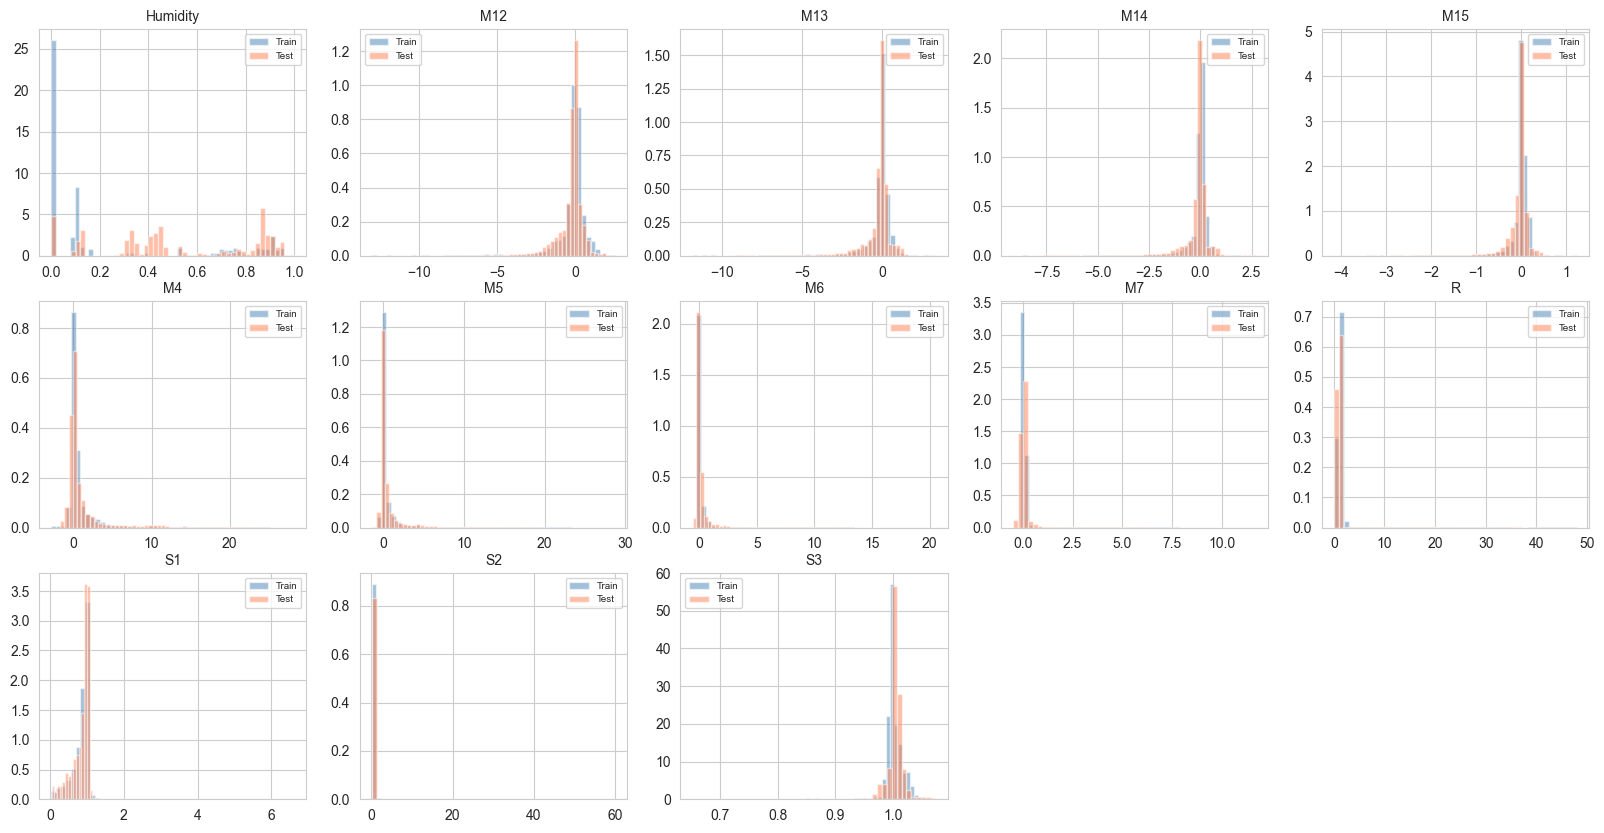

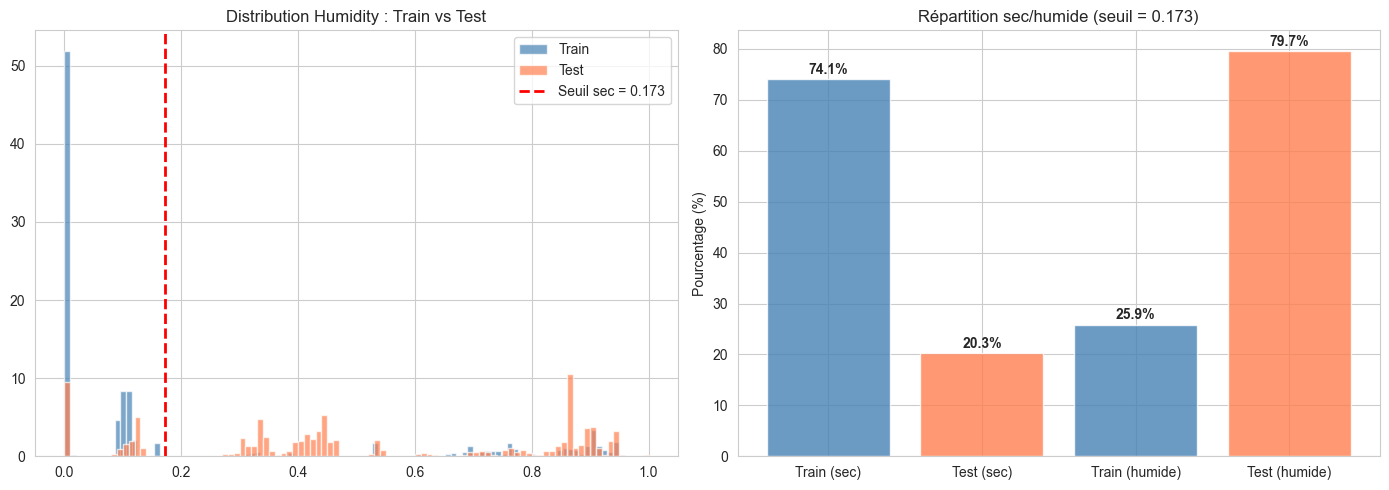

Train — sec (≤0.173) : 74.1%  |  humide : 25.9%
Test  — sec (≤0.173) : 20.3%  |  humide : 79.7%


In [6]:
# ============================================================
# EDA — Distributions train vs test
# ============================================================
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    ax.hist(dfX[col].dropna(), bins=50, alpha=0.5, color='steelblue',
            label='Train', density=True)
    ax.hist(dftest[col].dropna(), bins=50, alpha=0.5, color='coral',
            label='Test', density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

# Zoom humidité sec/humide
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
axes2[0].hist(dfX['Humidity'], bins=100, alpha=0.7, label='Train', color='steelblue', density=True)
axes2[0].hist(dftest['Humidity'], bins=100, alpha=0.7, label='Test', color='coral', density=True)
axes2[0].axvline(x=DRY_THRESH, color='red', linestyle='--', linewidth=2, label=f'Seuil sec = {DRY_THRESH}')
axes2[0].set_title('Distribution Humidity : Train vs Test')
axes2[0].legend()

pct_train_dry = (dfX['Humidity'] <= DRY_THRESH).mean() * 100
pct_test_dry  = (dftest['Humidity'] <= DRY_THRESH).mean() * 100
bars = axes2[1].bar(['Train (sec)', 'Test (sec)', 'Train (humide)', 'Test (humide)'],
                    [pct_train_dry, pct_test_dry, 100-pct_train_dry, 100-pct_test_dry],
                    color=['steelblue','coral','steelblue','coral'], alpha=0.8)
axes2[1].set_ylabel('Pourcentage (%)')
axes2[1].set_title(f'Répartition sec/humide (seuil = {DRY_THRESH})')
for bar, val in zip(bars, [pct_train_dry, pct_test_dry, 100-pct_train_dry, 100-pct_test_dry]):
    axes2[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Train — sec (≤{DRY_THRESH}) : {pct_train_dry:.1f}%  |  humide : {100-pct_train_dry:.1f}%')
print(f'Test  — sec (≤{DRY_THRESH}) : {pct_test_dry:.1f}%  |  humide : {100-pct_test_dry:.1f}%')


[3/8] Rééquilibrage hybride humidité...
  Avant rebalancing : 202933 lignes
  Sec (≤0.173) dans train : 150419 (74.1%)
  Sec (≤0.173) dans test  : 27393 (20.3%)
  Après rebalancing : 109202 lignes


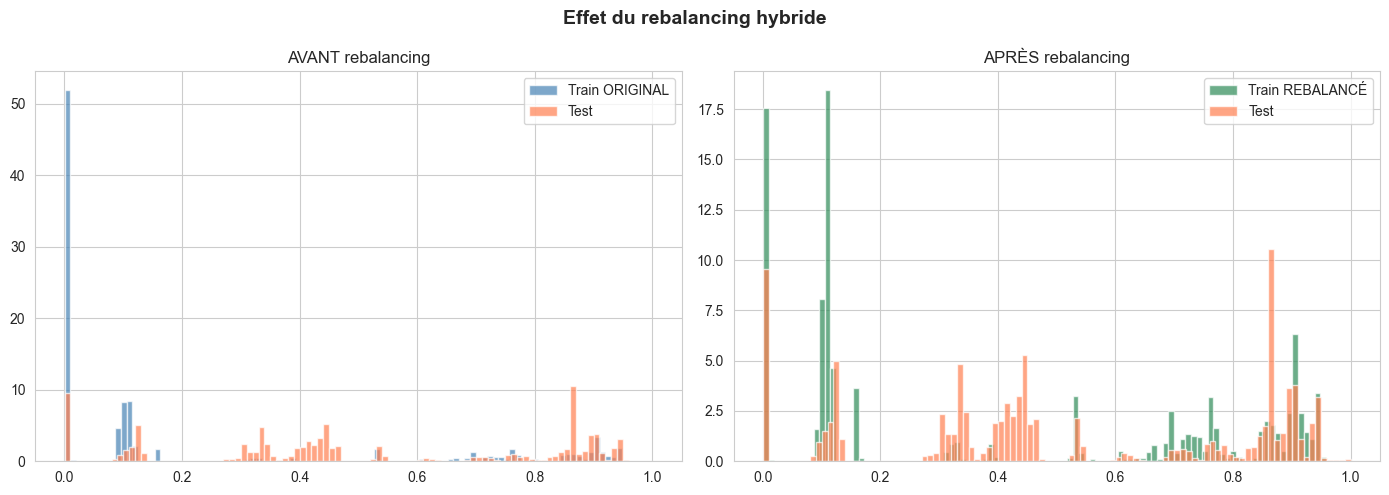

  Zone de transition [0.1, 0.173] : 34643 échantillons (surpoids)


In [ ]:
# ============================================================
# 3/8 — RÉÉQUILIBRAGE HYBRIDE DE L'HUMIDITÉ
# ============================================================

def balance_humidity(dfX, dfY, dftest):
    """
    Stratégie hybride :
    - Sous-échantillonne les données sèches (≤ 0.173) pour matcher le test
    - Conserve TOUTES les données avec Humidity > 0.1
    - Crée un chevauchement intentionnel dans [0.1, 0.173]
      qui agit comme un surpoids sur la zone charnière
    """
    dfX = dfX.reset_index(drop=True)
    dfY = dfY.reset_index(drop=True)

    n_test_dry  = (dftest['Humidity'] <= DRY_THRESH).sum()
    n_train_dry = (dfX['Humidity']    <= DRY_THRESH).sum()

    print(f'  Avant rebalancing : {len(dfX)} lignes')
    print(f'  Sec (≤{DRY_THRESH}) dans train : {n_train_dry} ({n_train_dry/len(dfX)*100:.1f}%)')
    print(f'  Sec (≤{DRY_THRESH}) dans test  : {n_test_dry} ({n_test_dry/len(dftest)*100:.1f}%)')

    if n_train_dry > n_test_dry:
        rng = np.random.RandomState(42)

        # Secs à sous-échantillonner
        h0_idx  = dfX[dfX['Humidity'] <= DRY_THRESH].index
        # Humides — seuil 0.1 (pas 0.173 !) → conserve la zone de transition
        nh0_idx = dfX[dfX['Humidity'] > 0.1].index

        h0_keep = pd.Index(rng.choice(h0_idx, size=n_test_dry, replace=False))
        keep = h0_keep.append(nh0_idx)
        keep = keep[rng.permutation(len(keep))]

        dfX = dfX.loc[keep].reset_index(drop=True)
        dfY = dfY.loc[keep].reset_index(drop=True)

    print(f'  Après rebalancing : {len(dfX)} lignes')
    return dfX, dfY

print('[3/8] Rééquilibrage hybride humidité...')
dfX_bal, dfY_bal = balance_humidity(dfX.copy(), dfY.copy(), dftest)

# Visu avant/après
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(dfX['Humidity'], bins=100, alpha=0.7, label='Train ORIGINAL', color='steelblue', density=True)
axes[0].hist(dftest['Humidity'], bins=100, alpha=0.7, label='Test', color='coral', density=True)
axes[0].set_title('AVANT rebalancing')
axes[0].legend()

axes[1].hist(dfX_bal['Humidity'], bins=100, alpha=0.7, label='Train REBALANCÉ', color='seagreen', density=True)
axes[1].hist(dftest['Humidity'], bins=100, alpha=0.7, label='Test', color='coral', density=True)
axes[1].set_title('APRÈS rebalancing')
axes[1].legend()

plt.suptitle('Effet du rebalancing hybride', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

transition = dfX_bal[(dfX_bal['Humidity'] > 0.1) & (dfX_bal['Humidity'] <= DRY_THRESH)]
print(f'  Zone de transition [0.1, {DRY_THRESH}] : {len(transition)} échantillons (surpoids)')

[4/8] Feature engineering...
[Train] 13 colonnes brutes → 84 features
[Test] 13 colonnes brutes → 84 features
  ✔ Terminé en 0.5s


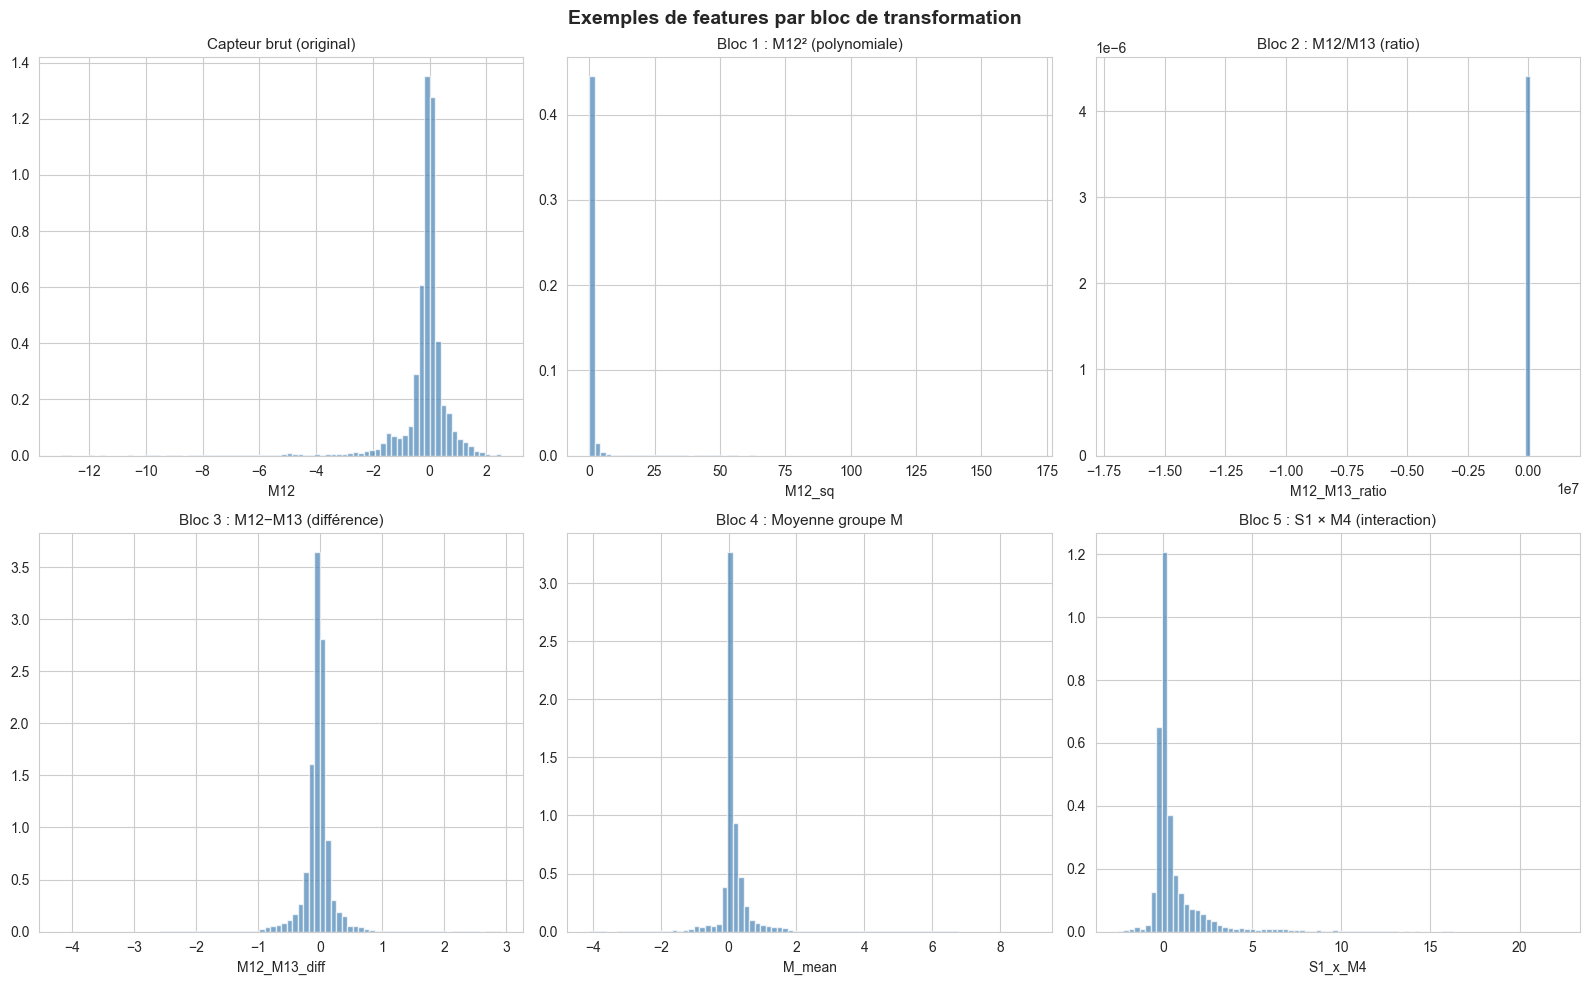

In [ ]:
# ============================================================
# 4/8 — FEATURE ENGINEERING (~84 features)
# ============================================================

def prepare_features(df, label=""):
    """
    Génère ~84 features à partir des 13 colonnes brutes.
    5 blocs : Polynomiales, Ratios, Différences, Stats de groupe, Cross-interactions.
    """
    available = [c for c in FEATURE_COLS if c in df.columns]
    base = df[available].copy().reset_index(drop=True)
    extras = {}

    # ── BLOC 1 : Transformations polynomiales ──
    for col in available[1:]:  # skip Humidity
        extras[f'{col}_sq']   = base[col] ** 2
        extras[f'{col}_sqrt'] = np.sqrt(np.abs(base[col]))
        extras[f'{col}_log']  = np.log1p(np.abs(base[col]))

    # ── BLOC 2 : Ratios consécutifs ──
    sensor_cols = available[1:]
    for i in range(len(sensor_cols) - 1):
        denom = base[sensor_cols[i+1]].replace(0, 1e-9)
        extras[f'{sensor_cols[i]}_{sensor_cols[i+1]}_ratio'] = base[sensor_cols[i]] / denom

    # ── BLOC 3 : Différences consécutives ──
    for i in range(len(sensor_cols) - 1):
        extras[f'{sensor_cols[i]}_{sensor_cols[i+1]}_diff'] = (
            base[sensor_cols[i]] - base[sensor_cols[i+1]]
        )

    # ── BLOC 4 : Statistiques de groupe ──
    m_cols = [c for c in ['M4','M5','M6','M7','M12','M13','M14','M15'] if c in base.columns]
    s_cols = [c for c in ['S1','S2','S3'] if c in base.columns]

    if m_cols:
        extras['M_mean'] = base[m_cols].mean(axis=1)
        extras['M_std']  = base[m_cols].std(axis=1)
        extras['M_max']  = base[m_cols].max(axis=1)
        extras['M_min']  = base[m_cols].min(axis=1)
    if s_cols:
        extras['S_mean'] = base[s_cols].mean(axis=1)
        extras['S_std']  = base[s_cols].std(axis=1)
    if m_cols and s_cols:
        extras['M_S_diff'] = base[m_cols].mean(axis=1) - base[s_cols].mean(axis=1)
    if 'R' in base.columns and 'Humidity' in base.columns:
        extras['R_Humidity_ratio'] = base['R'] / base['Humidity'].replace(0, 1e-9)

    # ── BLOC 5 : Interactions croisées ──
    for a, b in [('S1','M4'), ('S2','M5'), ('S3','M6'), ('R','S1'), ('R','M4')]:
        if a in base.columns and b in base.columns:
            extras[f'{a}_x_{b}'] = base[a] * base[b]

    result = pd.concat([base, pd.DataFrame(extras, index=base.index)], axis=1)
    result = result.loc[:, ~result.columns.duplicated()]

    print(f'[{label}] {len(available)} colonnes brutes → {result.shape[1]} features')
    return result

print('[4/8] Feature engineering...')
t0 = time.time()

X_train_feat = prepare_features(dfX_bal, label="Train")
X_test_feat  = prepare_features(dftest,  label="Test")

print(f'  ✔ Terminé en {time.time()-t0:.1f}s')

# Visu exemples
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
examples = [
    ('M12', 'Capteur brut (original)'),
    ('M12_sq', 'Bloc 1 : M12² (polynomiale)'),
    ('M12_M13_ratio', 'Bloc 2 : M12/M13 (ratio)'),
    ('M12_M13_diff', 'Bloc 3 : M12−M13 (différence)'),
    ('M_mean', 'Bloc 4 : Moyenne groupe M'),
    ('S1_x_M4', 'Bloc 5 : S1 × M4 (interaction)'),
]
for ax, (col, title) in zip(axes.flat, examples):
    if col in X_train_feat.columns:
        ax.hist(X_train_feat[col], bins=80, alpha=0.7, color='steelblue', density=True)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel(col)
plt.suptitle('Exemples de features par bloc de transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


[5/8] Nettoyage et density ratio weighting...
  X_train : (109202, 84)
  X_test  : (134673, 84)
  y_mat   : (109202, 16) (targets uniques)
  Domain accuracy : 0.688
  Poids — min: 0.290, max: 3.219, mean: 1.000, std: 0.236


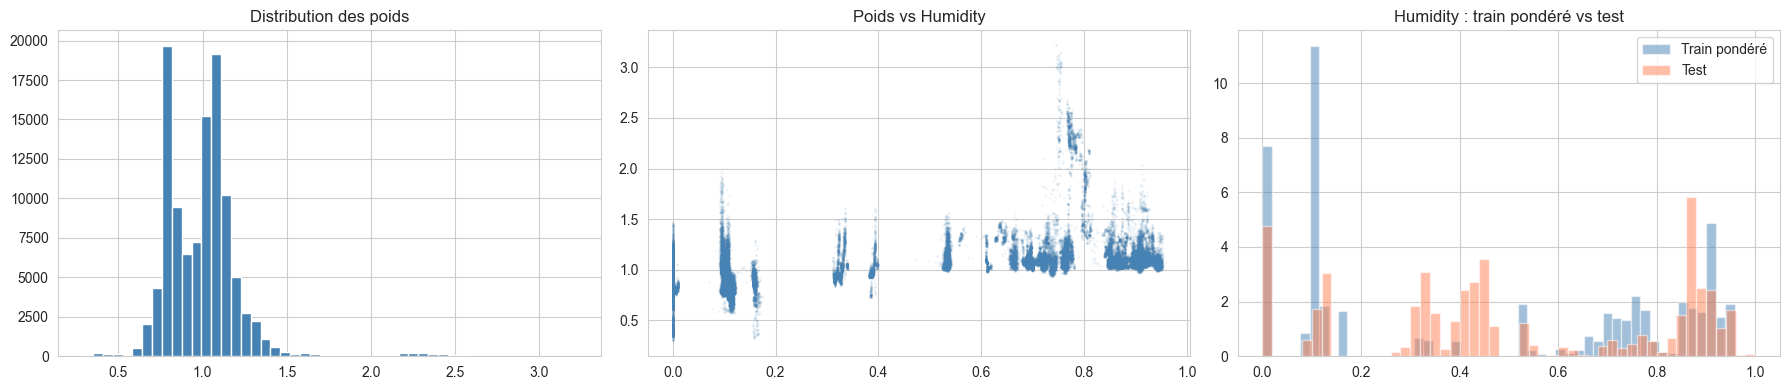

  ✔ Terminé en 4.1s


In [9]:
# ============================================================
# 5/8 — NETTOYAGE + DENSITY RATIO WEIGHTING
# ============================================================
# (Ton point fort : pondération des échantillons train
#  pour rapprocher la distribution du test)

print('[5/8] Nettoyage et density ratio weighting...')
t0 = time.time()

# Alignement colonnes
for col in X_train_feat.columns:
    if col not in X_test_feat.columns:
        X_test_feat[col] = 0
X_test_feat = X_test_feat[X_train_feat.columns]

# Nettoyage inf/NaN
X_train_clean = X_train_feat.replace([np.inf, -np.inf], 0).fillna(0)
X_test_clean  = X_test_feat.replace([np.inf, -np.inf], 0).fillna(0)

y_mat = dfY_bal[UNIQUE_TARGETS].values.astype(np.float32)

print(f'  X_train : {X_train_clean.shape}')
print(f'  X_test  : {X_test_clean.shape}')
print(f'  y_mat   : {y_mat.shape} (targets uniques)')

# ── Density Ratio Weighting ──
X_combined = pd.concat([X_train_clean, X_test_clean], axis=0, ignore_index=True)
y_domain   = np.array([0]*len(X_train_clean) + [1]*len(X_test_clean))

domain_clf = ExtraTreesClassifier(
    n_estimators=100, max_depth=5,
    random_state=42, n_jobs=-1, class_weight='balanced'
)
domain_clf.fit(X_combined, y_domain)

p_test = domain_clf.predict_proba(X_train_clean)[:, 1]
p_test_clipped = np.clip(p_test, 0.05, 0.95)
sample_weights = p_test_clipped / (1 - p_test_clipped)
sample_weights = sample_weights / sample_weights.mean()

print(f'  Domain accuracy : {domain_clf.score(X_combined, y_domain):.3f}')
print(f'  Poids — min: {sample_weights.min():.3f}, max: {sample_weights.max():.3f}, '
      f'mean: {sample_weights.mean():.3f}, std: {sample_weights.std():.3f}')

# Visu
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(sample_weights, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des poids')
axes[1].scatter(dfX_bal['Humidity'], sample_weights, alpha=0.05, s=1, c='steelblue')
axes[1].set_title('Poids vs Humidity')
axes[2].hist(dfX_bal['Humidity'], bins=50, weights=sample_weights,
             alpha=0.5, color='steelblue', label='Train pondéré', density=True)
axes[2].hist(dftest['Humidity'], bins=50, alpha=0.5, color='coral', label='Test', density=True)
axes[2].set_title('Humidity : train pondéré vs test')
axes[2].legend()
plt.tight_layout()
plt.show()

print(f'  ✔ Terminé en {time.time()-t0:.1f}s')


In [10]:
# ============================================================
# 6/8 — SPLIT VALIDATION
# ============================================================
print('[6/8] Split validation...')

X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
    X_train_clean, y_mat, sample_weights,
    test_size=0.2, random_state=42
)

print(f'  Train      : {X_tr.shape}')
print(f'  Validation : {X_val.shape}')
print(f'  Poids train — mean: {w_tr.mean():.3f}, std: {w_tr.std():.3f}')


[6/8] Split validation...
  Train      : (87361, 84)
  Validation : (21841, 84)
  Poids train — mean: 0.999, std: 0.236


In [11]:
# ============================================================
# UTILITAIRE : expansion des prédictions uniques → 23 targets
# ============================================================
# (Ton point fort : gestion automatique des duplicats)

def expand_predictions(preds_unique, unique_targets, target_cols, dup_map, zero_targets):
    """Reconstruit les 23 colonnes à partir des targets uniques."""
    full = np.zeros((preds_unique.shape[0], len(target_cols)))
    for j, col in enumerate(target_cols):
        if col in zero_targets:
            full[:, j] = 0.0
        elif col in dup_map:
            ref = dup_map[col]
            ref_idx = unique_targets.index(ref)
            full[:, j] = preds_unique[:, ref_idx]
        else:
            ref_idx = unique_targets.index(col)
            full[:, j] = preds_unique[:, ref_idx]
    return full

print('✔ Fonction expand_predictions définie')
print(f'  {len(UNIQUE_TARGETS)} modèles → {len(TARGET_COLS)} colonnes de soumission')


✔ Fonction expand_predictions définie
  16 modèles → 23 colonnes de soumission


In [ ]:
# ============================================================
# 7/8 — ENSEMBLE DIVERSIFIÉ (RF + ET, multi-seeds)
# ============================================================

def build_estimator(kind, n_estimators, max_depth, min_samples_leaf, random_state):
    common = dict(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=5,
        min_samples_leaf=min_samples_leaf,
        max_features='sqrt',
        n_jobs=-1,
        random_state=random_state,
    )
    if kind == 'RF':
        return RandomForestRegressor(**common)
    return ExtraTreesRegressor(**common)

# Configuration des 5 membres
ENSEMBLE_MEMBERS = [
    # (kind, label,       n_est, depth, leaf, seed)
    ('RF', 'RF_seed42',   300,   20,    2,    42),
    ('RF', 'RF_seed123',  300,   20,    2,    123),
    ('RF', 'RF_seed456',  300,   20,    2,    456),
    ('ET', 'ET∞_seed42',  300,   None,  2,    42),
    ('ET', 'ET∞_seed123', 300,   None,  2,    123),
]

print('[7/8] Entraînement de l\'ensemble diversifié...')
print(f'  {len(ENSEMBLE_MEMBERS)} modèles × {len(UNIQUE_TARGETS)} targets uniques')
print()
print(f'{"#":>3} {"Label":>14} {"Type":>4} {"Arbres":>7} {"Depth":>6} {"Seed":>5}')
print('-' * 50)
for i, (kind, label, n_est, depth, leaf, seed) in enumerate(ENSEMBLE_MEMBERS, 1):
    d = str(depth) if depth is not None else '∞'
    print(f'{i:>3} {label:>14} {kind:>4} {n_est:>7} {d:>6} {seed:>5}')
print()

# ── Entraînement sur le split de validation ──
member_val_preds = []
member_scores = []

for kind, label, n_est, depth, leaf, seed in ENSEMBLE_MEMBERS:
    t0 = time.time()

    preds_unique = np.zeros((len(X_val), len(UNIQUE_TARGETS)))

    for i, target in enumerate(UNIQUE_TARGETS):
        model = build_estimator(kind, n_est, depth, leaf, seed)
        model.fit(X_tr, y_tr[:, i], sample_weight=w_tr)
        preds_unique[:, i] = model.predict(X_val)

    # Expand + clip
    preds_full = expand_predictions(preds_unique, UNIQUE_TARGETS, TARGET_COLS,
                                     DUPLICATE_MAP, ZERO_TARGETS)
    preds_full = np.clip(preds_full, 0, 1)

    y_val_full = expand_predictions(y_val, UNIQUE_TARGETS, TARGET_COLS,
                                     DUPLICATE_MAP, ZERO_TARGETS)

    rmse = weighted_rmse(y_val_full, preds_full)
    elapsed = time.time() - t0

    print(f'  {label:>14} : WRMSE = {rmse:.6f}  ({elapsed:.0f}s)')

    member_val_preds.append(preds_unique)
    member_scores.append({'label': label, 'kind': kind, 'rmse': rmse})


[7/8] Entraînement de l'ensemble diversifié...
  5 modèles × 16 targets uniques

  #          Label Type  Arbres  Depth  Seed
--------------------------------------------------
  1      RF_seed42   RF     300     20    42
  2     RF_seed123   RF     300     20   123
  3     RF_seed456   RF     300     20   456
  4     ET∞_seed42   ET     300      ∞    42
  5    ET∞_seed123   ET     300      ∞   123

       RF_seed42 : WRMSE = 0.014742  (461s)
      RF_seed123 : WRMSE = 0.014670  (443s)
      RF_seed456 : WRMSE = 0.014684  (432s)
      ET∞_seed42 : WRMSE = 0.015073  (114s)
     ET∞_seed123 : WRMSE = 0.014940  (114s)



COMPARAISON DES COMBINAISONS D'ENSEMBLE
Ensemble                                   #      WRMSE
----------------------------------------------------------------------
RF seul (seed 42)                          1   0.014742 ★
RF ×3 (multi-seeds)                        3   0.014614 ★
ET∞ ×2                                     2   0.014943
RF ×3 + ET∞ ×2 (ensemble complet)          5   0.014397 ★
★ Meilleur : RF ×3 + ET∞ ×2 (ensemble complet) → 0.014397


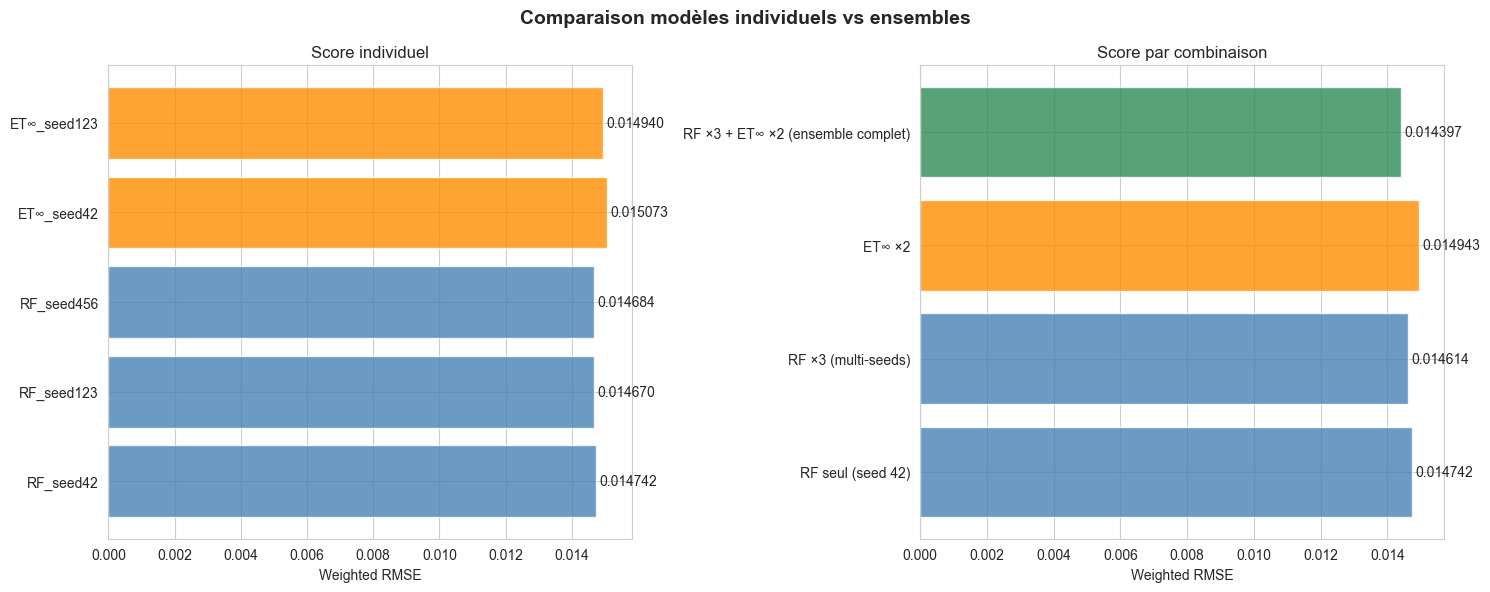

In [13]:
# ============================================================
# COMPARAISON DES COMBINAISONS D'ENSEMBLE
# ============================================================
preds_stack = np.stack(member_val_preds, axis=0)  # (5, n_val, n_unique)

rf_indices = [i for i, (k, *_) in enumerate(ENSEMBLE_MEMBERS) if k == 'RF']
et_indices = [i for i, (k, *_) in enumerate(ENSEMBLE_MEMBERS) if k == 'ET']

combos = [
    ('RF seul (seed 42)',                  [0]),
    ('RF ×3 (multi-seeds)',                rf_indices),
    ('ET∞ ×2',                             et_indices),
    ('RF ×3 + ET∞ ×2 (ensemble complet)', list(range(5))),
]

y_val_full = expand_predictions(y_val, UNIQUE_TARGETS, TARGET_COLS,
                                 DUPLICATE_MAP, ZERO_TARGETS)

print()
print('=' * 70)
print('COMPARAISON DES COMBINAISONS D\'ENSEMBLE')
print('=' * 70)
print(f'{"Ensemble":<40} {"#":>3} {"WRMSE":>10}')
print('-' * 70)

results_combo = []
for name, idx_list in combos:
    ens_pred_unique = np.mean(preds_stack[idx_list], axis=0)
    ens_pred_full = expand_predictions(ens_pred_unique, UNIQUE_TARGETS, TARGET_COLS,
                                        DUPLICATE_MAP, ZERO_TARGETS)
    ens_pred_full = np.clip(ens_pred_full, 0, 1)
    ens_rmse = weighted_rmse(y_val_full, ens_pred_full)

    marker = ''
    if results_combo:
        if ens_rmse <= min(r['rmse'] for r in results_combo):
            marker = ' ★'
    else:
        marker = ' ★'

    print(f'{name:<40} {len(idx_list):>3} {ens_rmse:>10.6f}{marker}')
    results_combo.append({'name': name, 'n': len(idx_list), 'rmse': ens_rmse, 'idx': idx_list})

best_combo = min(results_combo, key=lambda x: x['rmse'])
print('=' * 70)
print(f'★ Meilleur : {best_combo["name"]} → {best_combo["rmse"]:.6f}')

# Visu
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
labels_ind = [s['label'] for s in member_scores]
rmses_ind  = [s['rmse'] for s in member_scores]
colors_ind = ['steelblue' if s['kind'] == 'RF' else 'darkorange' for s in member_scores]

bars1 = axes[0].barh(labels_ind, rmses_ind, color=colors_ind, alpha=0.8)
axes[0].set_xlabel('Weighted RMSE')
axes[0].set_title('Score individuel')
for bar, val in zip(bars1, rmses_ind):
    axes[0].text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                 f'{val:.6f}', va='center', fontsize=10)

labels_ens = [r['name'] for r in results_combo]
rmses_ens  = [r['rmse'] for r in results_combo]
colors_ens = ['steelblue', 'steelblue', 'darkorange', 'seagreen']

bars2 = axes[1].barh(labels_ens, rmses_ens, color=colors_ens, alpha=0.8)
axes[1].set_xlabel('Weighted RMSE')
axes[1].set_title('Score par combinaison')
for bar, val in zip(bars2, rmses_ens):
    axes[1].text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                 f'{val:.6f}', va='center', fontsize=10)

plt.suptitle('Comparaison modèles individuels vs ensembles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Calcul des feature importances...


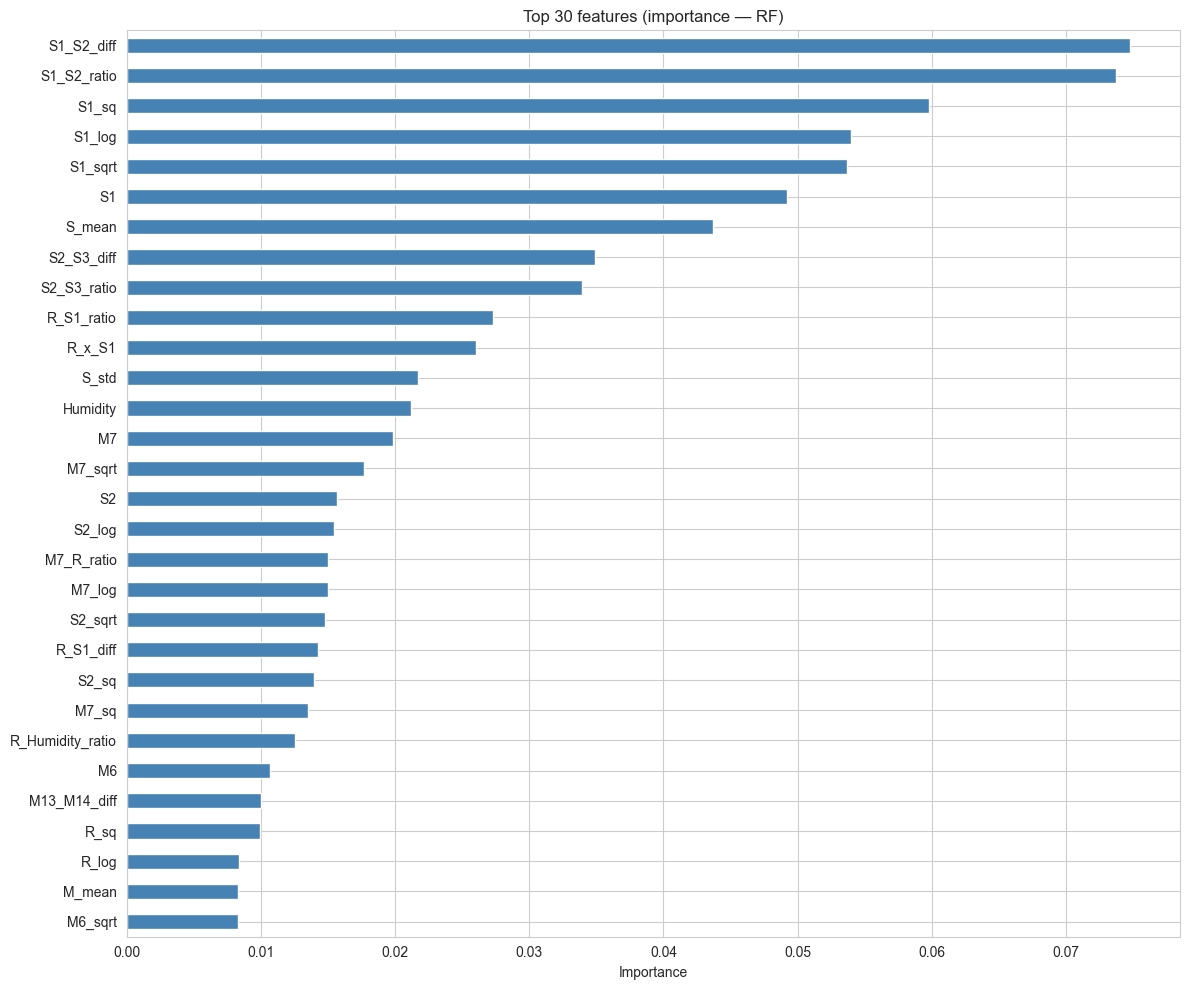


Top 15 features :
  S1_S2_diff                : 0.0748
  S1_S2_ratio               : 0.0738
  S1_sq                     : 0.0598
  S1_log                    : 0.0540
  S1_sqrt                   : 0.0537
  S1                        : 0.0492
  S_mean                    : 0.0437
  S2_S3_diff                : 0.0349
  S2_S3_ratio               : 0.0339
  R_S1_ratio                : 0.0273
  R_x_S1                    : 0.0260
  S_std                     : 0.0217
  Humidity                  : 0.0212
  M7                        : 0.0198
  M7_sqrt                   : 0.0177


In [14]:
# ============================================================
# FEATURE IMPORTANCE (premier modèle RF)
# ============================================================
# On ré-entraîne un seul RF pour les importances
print('Calcul des feature importances...')

imp_model = build_estimator('RF', 300, 20, 2, 42)
# Fit sur une target représentative
imp_model.fit(X_tr, y_tr[:, 0], sample_weight=w_tr)

mean_imp = pd.Series(imp_model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 10))
mean_imp.head(30).plot(kind='barh', color='steelblue')
plt.title('Top 30 features (importance — RF)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 15 features :')
for feat, imp in mean_imp.head(15).items():
    print(f'  {feat:<25} : {imp:.4f}')


In [ ]:
# ============================================================
# 8/8 — REFIT SUR 100% + SOUMISSION
# ============================================================

best_idx = best_combo['idx']
best_members = [ENSEMBLE_MEMBERS[i] for i in best_idx]

print(f'[8/8] Refit sur 100% des données ({len(X_train_clean)} lignes)...')
print(f'  Meilleur ensemble : {best_combo["name"]}')
print(f'  Membres : {[m[1] for m in best_members]}')
print()

test_predictions = []

for kind, label, n_est, depth, leaf, seed in best_members:
    t0 = time.time()

    preds_unique = np.zeros((len(X_test_clean), len(UNIQUE_TARGETS)))

    for i, target in enumerate(UNIQUE_TARGETS):
        model = build_estimator(kind, n_est, depth, leaf, seed)
        # Refit sur 100% du train avec sample_weights
        model.fit(X_train_clean, y_mat[:, i], sample_weight=sample_weights)
        preds_unique[:, i] = model.predict(X_test_clean)

    test_predictions.append(preds_unique)
    d = str(depth) if depth is not None else '∞'
    print(f'  {label:>14} refit 100% → OK  ({time.time()-t0:.0f}s)')

# ── Moyenne des prédictions + expand ──
mean_preds_unique = np.mean(np.stack(test_predictions, axis=0), axis=0)
final_pred = expand_predictions(mean_preds_unique, UNIQUE_TARGETS, TARGET_COLS,
                                 DUPLICATE_MAP, ZERO_TARGETS)
final_pred = np.clip(final_pred, 0, 1)

print(f'\nPrédictions finales : {final_pred.shape}')
print(f'  Min  : {final_pred.min():.6f}')
print(f'  Max  : {final_pred.max():.6f}')
print(f'  Mean : {final_pred.mean():.6f}')

# ── Soumission ──
pred_df = pd.DataFrame(final_pred, columns=TARGET_COLS)
if 'ID' in dftest_raw.columns:
    pred_df.insert(0, 'ID', dftest_raw['ID'].values)

pred_df.to_csv('submission_v4.csv', index=False)

print(f'\n  ✔ submission_v4.csv sauvegardé  {pred_df.shape}')
print(f'  Score validation : {best_combo["rmse"]:.5f}')
display(pred_df.head(10))


[8/8] Refit sur 100% des données (109202 lignes)...
  Meilleur ensemble : RF ×3 + ET∞ ×2 (ensemble complet)
  Membres : ['RF_seed42', 'RF_seed123', 'RF_seed456', 'ET∞_seed42', 'ET∞_seed123']

       RF_seed42 refit 100% → OK  (560s)
      RF_seed123 refit 100% → OK  (556s)
      RF_seed456 refit 100% → OK  (565s)
      ET∞_seed42 refit 100% → OK  (167s)
     ET∞_seed123 refit 100% → OK  (164s)

Prédictions finales : (134673, 23)
  Min  : 0.000000
  Max  : 0.982698
  Mean : 0.105474

  ✔ submission_v4.csv sauvegardé  (134673, 24)
  Score validation : 0.01440


,ID,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c14,c15,c16,c17,c18,c19,c20,c21,c22,c23
0,202933,0.000325,0.001364,0.004839,0.004839,0.000011,0.000011,0.001364,0.000024,0.000049,...,0.001114,0.0,0.002311,0.000873,0.000049,0.000000,0.001364,0.000011,0.004839,0.001992
1,202934,0.330550,0.000238,0.565204,0.565204,0.000079,0.000079,0.000238,0.000000,0.001293,...,0.397904,0.0,0.015751,0.003931,0.000358,0.003602,0.000238,0.000079,0.565204,0.040327
2,202935,0.045158,0.013986,0.207303,0.207303,0.159002,0.159002,0.013986,0.000653,0.000138,...,0.012857,0.0,0.000375,0.011877,0.012946,0.002441,0.013986,0.159002,0.207303,0.038114
3,202936,0.039592,0.023050,0.258628,0.258628,0.125592,0.125592,0.023050,0.000671,0.018625,...,0.017004,0.0,0.000990,0.071716,0.026534,0.047849,0.023050,0.125592,0.258628,0.067786
4,202937,0.085591,0.025591,0.162423,0.162423,0.007832,0.007832,0.025591,0.000912,0.009828,...,0.021459,0.0,0.001108,0.029713,0.008516,0.028890,0.025591,0.007832,0.162423,0.113640
5,202938,0.093101,0.045780,0.275310,0.275310,0.002890,0.002890,0.045780,0.004757,0.015884,...,0.033158,0.0,0.000816,0.033159,0.014016,0.057451,0.045780,0.002890,0.275310,0.097135
6,202939,0.329688,0.003997,0.383520,0.383520,0.013832,0.013832,0.003997,0.000980,0.000212,...,0.085751,0.0,0.000000,0.001223,0.013531,0.000002,0.003997,0.013832,0.383520,0.006093
7,202940,0.754048,0.067280,0.788631,0.788631,0.000392,0.000392,0.067280,0.005241,0.000014,...,0.000844,0.0,0.000211,0.000270,0.764488,0.000318,0.067280,0.000392,0.788631,0.000220
8,202941,0.229943,0.002025,0.449131,0.449131,0.001835,0.001835,0.002025,0.000547,0.017886,...,0.187841,0.0,0.004475,0.004606,0.005475,0.010895,0.002025,0.001835,0.449131,0.029356
9,202942,0.811798,0.000069,0.796559,0.796559,0.002332,0.002332,0.000069,0.000467,0.000522,...,0.043372,0.0,0.000000,0.000000,0.014067,0.000346,0.000069,0.002332,0.796559,0.012277


Désaccord entre les membres (écart-type des prédictions) :
  Moyen  : 0.010376
  Max    : 0.258417
  Médian : 0.003620


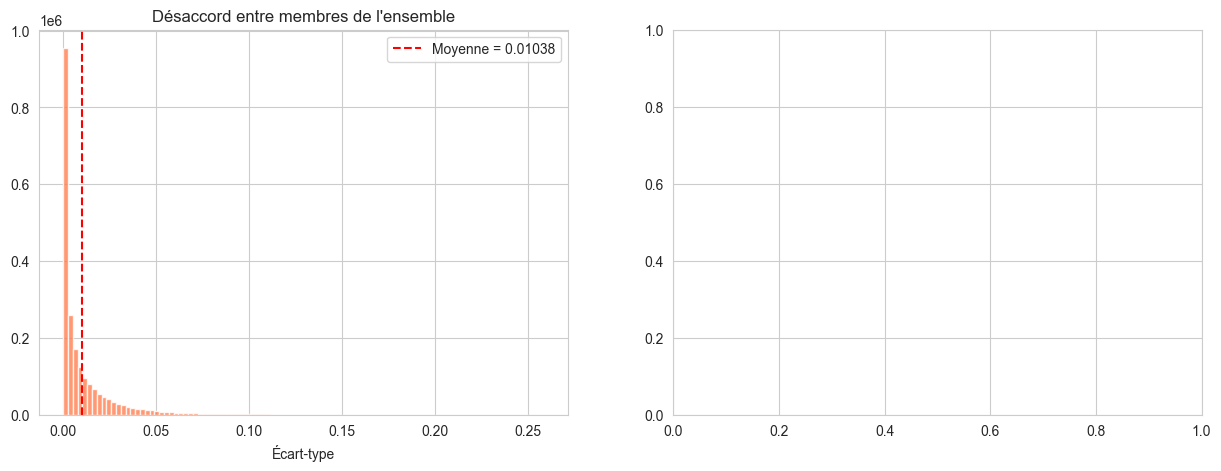

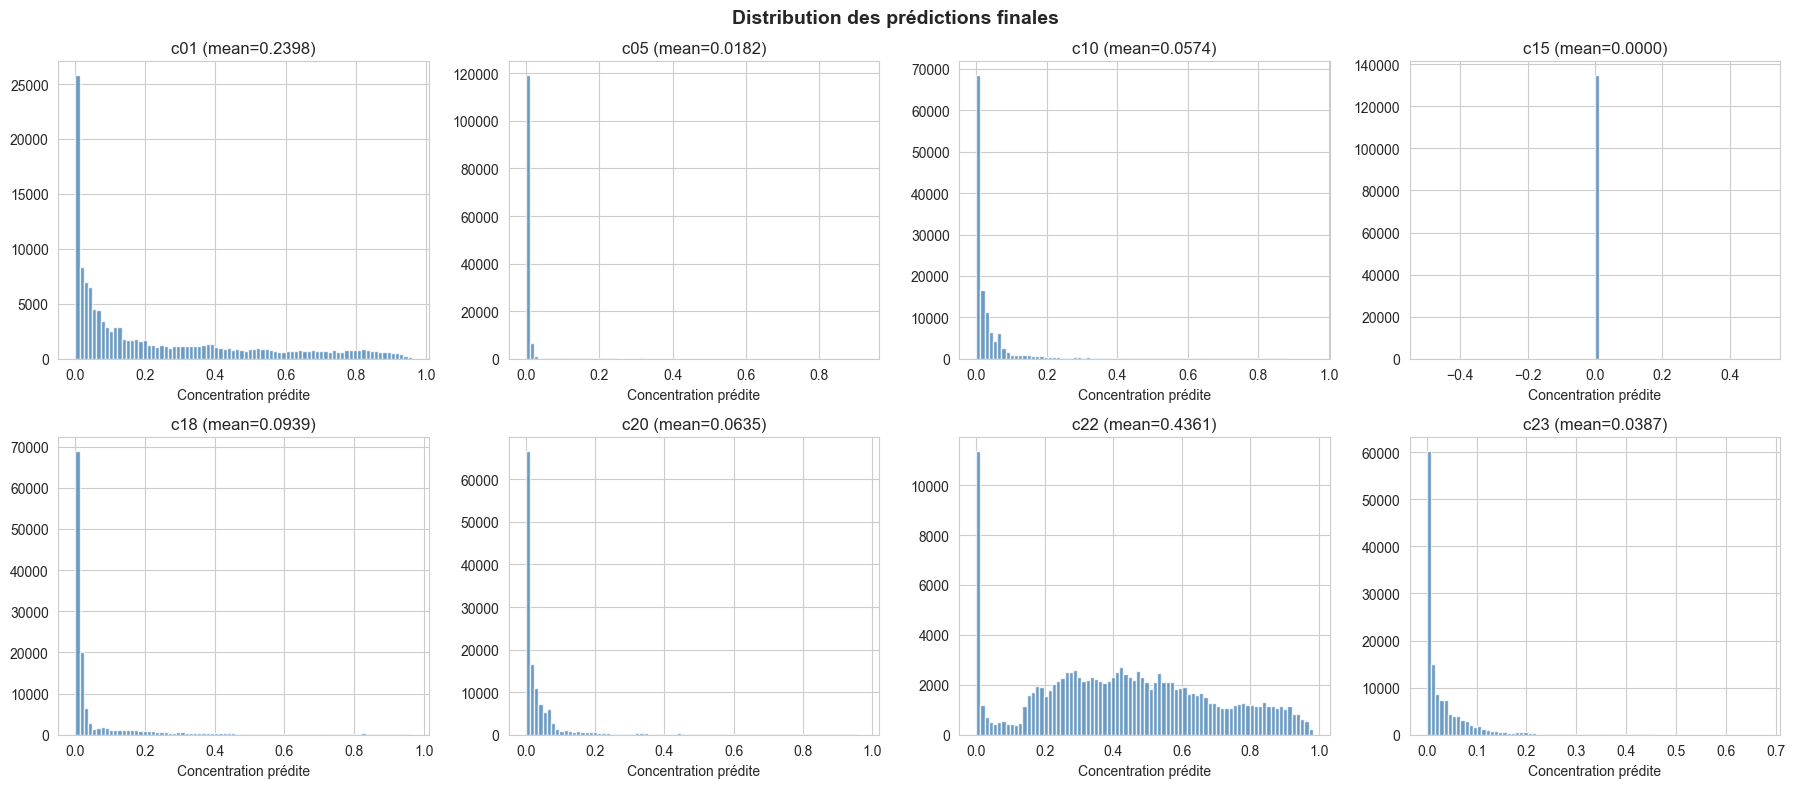

In [16]:
# ============================================================
# ANALYSE DE LA VARIANCE ENTRE MEMBRES
# ============================================================
preds_all = np.stack(test_predictions, axis=0)
pred_std = preds_all.std(axis=0)

print('Désaccord entre les membres (écart-type des prédictions) :')
print(f'  Moyen  : {pred_std.mean():.6f}')
print(f'  Max    : {pred_std.max():.6f}')
print(f'  Médian : {np.median(pred_std):.6f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(pred_std.flatten(), bins=100, alpha=0.8, color='coral')
axes[0].axvline(pred_std.mean(), color='red', linestyle='--', label=f'Moyenne = {pred_std.mean():.5f}')
axes[0].set_title('Désaccord entre membres de l\'ensemble')
axes[0].set_xlabel('Écart-type')
axes[0].legend()

# Distribution des prédictions pour quelques gaz
gases = ['c01', 'c05', 'c10', 'c15', 'c18', 'c20', 'c22', 'c23']
fig2, axes2 = plt.subplots(2, 4, figsize=(18, 8))
for ax, gas in zip(axes2.flat, gases):
    idx = TARGET_COLS.index(gas)
    vals = final_pred[:, idx]
    ax.hist(vals, bins=80, alpha=0.8, color='steelblue')
    ax.set_title(f'{gas} (mean={vals.mean():.4f})')
    ax.set_xlabel('Concentration prédite')

plt.suptitle('Distribution des prédictions finales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [49]:
# ============================================================
# RÉSUMÉ FINAL
# ============================================================
print('╔══════════════════════════════════════════════════════════════╗')
print('║              GAS DETECTOR v4 — RÉSUMÉ                        ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Features       : {X_train_clean.shape[1]:>4} (13 brutes → {X_train_clean.shape[1]} engineered)           ║')
print(f'║  Targets uniques: {len(UNIQUE_TARGETS):>4} / {len(TARGET_COLS)} (dédupliqués auto)               ║')
print(f'║  Rebalancing    : hybride seuil {DRY_THRESH} + transition           ║')
print(f'║  Weighting      : density ratio (domain classifier)          ║')
print(f'║  Ensemble       : {best_combo["name"]:<40}   ║')
print(f'║  Refit          : 100% des données                           ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  Scores individuels :                                        ║')
for s in member_scores:
    print(f'║    {s["label"]:>14} ({s["kind"]}) : {s["rmse"]:.6f}                            ║')
print('╠══════════════════════════════════════════════════════════════╣')
for r in results_combo:
    marker = '★' if r['name'] == best_combo['name'] else ''
    print(f'║  {marker} {r["name"]:<38} : {r["rmse"]:.6f}          ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  → Soumission : submission_v4.csv  ({pred_df.shape})            ║')
print('╚══════════════════════════════════════════════════════════════╝')


╔══════════════════════════════════════════════════════════════╗
║              GAS DETECTOR v4 — RÉSUMÉ                        ║
╠══════════════════════════════════════════════════════════════╣
║  Features       :   84 (13 brutes → 84 engineered)           ║
║  Targets uniques:   16 / 23 (dédupliqués auto)               ║
║  Rebalancing    : hybride seuil 0.173 + transition           ║
║  Weighting      : density ratio (domain classifier)          ║
║  Ensemble       : RF ×3 + ET∞ ×2 (ensemble complet)          ║
║  Refit          : 100% des données                           ║
╠══════════════════════════════════════════════════════════════╣
║  Scores individuels :                                        ║
║         RF_seed42 (RF) : 0.014742                            ║
║        RF_seed123 (RF) : 0.014670                            ║
║        RF_seed456 (RF) : 0.014684                            ║
║        ET∞_seed42 (ET) : 0.015073                            ║
║       ET∞_seed123 (ET) 